# Training semantic segmentation (DeepLabv3+ or PSPNet) in Google Colab with CVAT masks and Azure Blob storage

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/datasantana/sam-image-processing/blob/main/notebooks/semantic_segmentation_training.ipynb)

In [16]:
# 🔧 Install Dependencies
# Run this cell first when opening the notebook in Google Colab

!pip install azure-storage-blob>=12.17.0
!pip install opencv-python>=4.8.0
!pip install pillow>=10.0.0
!pip install numpy>=1.24.0
!pip install matplotlib>=3.7.0

print("🎉 Dependencies installed successfully!")

🎉 Dependencies installed successfully!


# 🛰️ Semantic Segmentation Training Setup

This notebook initializes the connection to Azure Blob Storage, downloads drone imagery and labeled masks, and prepares reproducible training and validation datasets for semantic segmentation using DeepLabv3+ or PSPNet.

**Dataset structure:**
- Images: `assets/drone-imagery`
- Masks: `assets/pascual_annotation_masks/SegmentationClass`
- Label map: `assets/pascual_annotation_masks/labelmap.txt`

**Azure Blob Storage:**
- Container: `general-purpose`
- Connection string: stored securely in `AZURE_CONN_STR`

## 1: Azure Blob Connection & Download

In [17]:
# 📦 Connect to Azure Blob Storage and download images and masks
from azure.storage.blob import BlobServiceClient
from google.colab import userdata
import os

# 🔐 Azure Connection Configuration
# Option 1: Set as environment variable (recommended for Colab)
# import os
AZURE_CONN_STR = userdata.get('AZURE_CONNECTION_STRING')

# Option 2: Use getpass for secure input (uncomment to use)
# from getpass import getpass
# AZURE_CONN_STR = getpass('Enter Azure Connection String: ')

# Option 3: Set directly (replace with your actual connection string)
# AZURE_CONN_STR = "DefaultEndpointsProtocol=...<place complete string here>"

if AZURE_CONN_STR == "DefaultEndpointsProtocol=...<place complete string here>":
    print("⚠️  Please set your Azure connection string!")
    print("Uncomment one of the options above or set AZURE_CONN_STR variable")
    raise ValueError("Azure connection string not configured")

CONTAINER_NAME = "general-purpose"

# Blob Storage paths (where data is stored in Azure)
LOCAL_IMG_DIR = "assets/drone-imagery"
LOCAL_MASK_DIR = "assets/pascual_annotation_masks/SegmentationClass"
LOCAL_LABELMAP_DIR = "assets/pascual_annotation_masks"

# Local directories (where to download files)
LOCAL_DOWNLOAD_IMG_DIR = "assets/images"
LOCAL_DOWNLOAD_MASK_DIR = "assets/masks"

os.makedirs(LOCAL_DOWNLOAD_IMG_DIR, exist_ok=True)
os.makedirs(LOCAL_DOWNLOAD_MASK_DIR, exist_ok=True)

# Connect to blob container
try:
    blob_service_client = BlobServiceClient.from_connection_string(AZURE_CONN_STR)
    container_client = blob_service_client.get_container_client(CONTAINER_NAME)
    print("✅ Successfully connected to Azure Blob Storage")
except Exception as e:
    print(f"❌ Failed to connect to Azure Blob Storage: {e}")
    raise

def download_blobs(prefix, local_dir, file_types=None):
    """
    Download blobs with optional file type filtering

    Args:
        prefix: Blob prefix to search for
        local_dir: Local directory to download to
        file_types: List of extensions (case-insensitive) or None to download all files
                   e.g., ['.jpg', '.jpeg', '.png'] or None
    """
    print(f"🔍 Looking for blobs with prefix '{prefix}'...")
    if file_types:
        print(f"   File types: {file_types} (case-insensitive)")
    else:
        print("   Downloading all file types")

    try:
        blobs = list(container_client.list_blobs(name_starts_with=prefix))
        print(f"📁 Found {len(blobs)} total blobs with prefix '{prefix}'")

        downloaded_count = 0
        for blob in blobs:
            print(f"  - Checking blob: {blob.name}")

            # Check file type if specified
            should_download = True
            if file_types:
                should_download = any(blob.name.lower().endswith(ext.lower()) for ext in file_types)

            if should_download:
                local_path = os.path.join(local_dir, os.path.basename(blob.name))
                if not os.path.exists(local_path):
                    print(f"    ⬇️ Downloading {blob.name} -> {local_path}")
                    try:
                        with open(local_path, "wb") as f:
                            blob_data = container_client.download_blob(blob.name).readall()
                            f.write(blob_data)
                        downloaded_count += 1
                        print(f"    ✅ Downloaded {blob.name} ({len(blob_data)} bytes)")
                    except Exception as e:
                        print(f"    ❌ Failed to download {blob.name}: {e}")
                else:
                    print(f"    ⏭️ Skipping {blob.name} (already exists)")
            else:
                print(f"    ⏭️ Skipping {blob.name} (file type not in {file_types})")

        print(f"📊 Downloaded {downloaded_count} files from {prefix} to {local_dir}")

    except Exception as e:
        print(f"❌ Error listing blobs with prefix '{prefix}': {e}")

# Download images and masks with flexible file type matching
# Images: Support common image formats (case-insensitive)
download_blobs(LOCAL_IMG_DIR, LOCAL_DOWNLOAD_IMG_DIR, ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'])

# Masks: Support common mask formats (case-insensitive)
download_blobs(LOCAL_MASK_DIR, LOCAL_DOWNLOAD_MASK_DIR, ['.png', '.jpg', '.jpeg', '.bmp'])

✅ Successfully connected to Azure Blob Storage
🔍 Looking for blobs with prefix 'assets/drone-imagery'...
   File types: ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'] (case-insensitive)
📁 Found 66 total blobs with prefix 'assets/drone-imagery'
  - Checking blob: assets/drone-imagery/DJI_20250522111442_0006_D.JPG
    ⏭️ Skipping assets/drone-imagery/DJI_20250522111442_0006_D.JPG (already exists)
  - Checking blob: assets/drone-imagery/DJI_20250522111502_0016_D.JPG
    ⏭️ Skipping assets/drone-imagery/DJI_20250522111502_0016_D.JPG (already exists)
  - Checking blob: assets/drone-imagery/DJI_20250522111506_0018_D.JPG
    ⏭️ Skipping assets/drone-imagery/DJI_20250522111506_0018_D.JPG (already exists)
  - Checking blob: assets/drone-imagery/DJI_20250522111534_0032_D.JPG
    ⏭️ Skipping assets/drone-imagery/DJI_20250522111534_0032_D.JPG (already exists)
  - Checking blob: assets/drone-imagery/DJI_20250522111552_0041_D.JPG
    ⏭️ Skipping assets/drone-imagery/DJI_20250522111552_0041_D.JPG

## 2: 🧪 Dataset Preparation

This section reads and sorts the downloaded images and masks, then creates a reproducible split using a configurable ratio (default 80/20) with a fixed random seed for reproducibility.

Each image is matched with its corresponding mask by filename.

In [18]:
# 🧪 Dataset Preparation — configurable train/val split
from sklearn.model_selection import train_test_split

# ─── Split Configuration ───
TRAIN_RATIO = 0.8           # Fraction of data used for training (0.0–1.0)
RANDOM_SEED = 42            # Fixed seed for reproducibility

# List and sort all image and mask files (no format validation)
image_files = sorted([f for f in os.listdir(LOCAL_DOWNLOAD_IMG_DIR)])
mask_files = sorted([f for f in os.listdir(LOCAL_DOWNLOAD_MASK_DIR)])

print(f"📁 Found {len(image_files)} image files")
print(f"📁 Found {len(mask_files)} mask files")

# Match image-mask pairs by base filename (remove extensions)
def get_base_name(filename):
    return os.path.splitext(filename)[0]

# Create pairs based on matching base names
image_base_names = {get_base_name(f): f for f in image_files}
mask_base_names = {get_base_name(f): f for f in mask_files}

# Find matching pairs
matching_base_names = set(image_base_names.keys()) & set(mask_base_names.keys())
pairs = [(image_base_names[base], mask_base_names[base]) for base in sorted(matching_base_names)]

print(f"🔗 Found {len(pairs)} matching image-mask pairs")

# Reproducible split using configurable ratio and fixed seed
train_pairs, val_pairs = train_test_split(
    pairs,
    train_size=TRAIN_RATIO,
    random_state=RANDOM_SEED,
    shuffle=True
)

# Build full path dictionaries
def build_dataset(pairs, img_dir, mask_dir):
    return [
        {
            "img_path": os.path.join(img_dir, img),
            "seg_map_path": os.path.join(mask_dir, mask)
        }
        for img, mask in pairs
    ]

train_dataset = build_dataset(train_pairs, LOCAL_DOWNLOAD_IMG_DIR, LOCAL_DOWNLOAD_MASK_DIR)
val_dataset = build_dataset(val_pairs, LOCAL_DOWNLOAD_IMG_DIR, LOCAL_DOWNLOAD_MASK_DIR)

print(f"✅ Train set: {len(train_dataset)} images ({TRAIN_RATIO*100:.0f}%)")
print(f"✅ Val set: {len(val_dataset)} images ({(1-TRAIN_RATIO)*100:.0f}%)")
print(f"🎲 Random seed: {RANDOM_SEED}")
print(f"📁 Images directory: {LOCAL_DOWNLOAD_IMG_DIR}")
print(f"📁 Masks directory: {LOCAL_DOWNLOAD_MASK_DIR}")
print(f"🔗 Blob source - Images: {LOCAL_IMG_DIR}")
print(f"🔗 Blob source - Masks: {LOCAL_MASK_DIR}")

📁 Found 66 image files
📁 Found 66 mask files
🔗 Found 66 matching image-mask pairs
✅ Train set: 52 images (80%)
✅ Val set: 14 images (20%)
🎲 Random seed: 42
📁 Images directory: assets/images
📁 Masks directory: assets/masks
🔗 Blob source - Images: assets/drone-imagery
🔗 Blob source - Masks: assets/pascual_annotation_masks/SegmentationClass


## 3: 🚀 Model Training Setup

Now we'll set up the semantic segmentation training pipeline with support for:
- **DeepLabv3+** with ResNet backbone
- **PSPNet** with ResNet backbone  
- Easy model switching
- Configurable training parameters
- Label map integration

### 3.1: 🔧 Deep Learning Environment Setup

In [19]:
# 🔧 Install Deep Learning Dependencies
# PyTorch and related packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install segmentation-models-pytorch>=0.3.3
!pip install albumentations>=1.3.0
!pip install timm>=0.9.0

# Additional ML utilities
!pip install scikit-learn>=1.3.0
!pip install tqdm>=4.65.0
!pip install tensorboard>=2.13.0

print("🎉 Deep learning environment setup complete!")

Looking in indexes: https://download.pytorch.org/whl/cu118
🎉 Deep learning environment setup complete!


### 3.2: 📋 Model Configuration

In [20]:
# 📋 Model and Training Configuration
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# 🎯 Model Selection - Change this to switch models
MODEL_ARCH = "DeepLabv3+"  # Options: "DeepLabv3+", "PSPNet"
BACKBONE = "resnet50"      # Options: "resnet18", "resnet34", "resnet50", "resnet101", "resnet152"

# 🏋️ Training Configuration
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_EPOCHS = 50
IMAGE_SIZE = 512
NUM_WORKERS = 2

# 📊 Model Architecture Settings
if MODEL_ARCH == "DeepLabv3+":
    print(f"🎯 Using DeepLabv3+ with {BACKBONE} backbone")
    model_class = smp.DeepLabV3Plus
elif MODEL_ARCH == "PSPNet":
    print(f"🎯 Using PSPNet with {BACKBONE} backbone")
    model_class = smp.PSPNet
else:
    raise ValueError(f"Unsupported model architecture: {MODEL_ARCH}")

# 🖥️ Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

# 📁 Output Configuration
MODEL_SAVE_DIR = "models"
LOGS_DIR = "logs"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(LOGS_DIR, exist_ok=True)

print(f"✅ Configuration complete!")
print(f"   Model: {MODEL_ARCH}")
print(f"   Backbone: {BACKBONE}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"   Epochs: {NUM_EPOCHS}")

🎯 Using DeepLabv3+ with resnet50 backbone
🖥️ Using device: cuda
✅ Configuration complete!
   Model: DeepLabv3+
   Backbone: resnet50
   Batch Size: 8
   Learning Rate: 0.0001
   Image Size: 512x512
   Epochs: 50


# 📘 Guía para Principiantes: ¿Cómo entender este Notebook?

¡Bienvenido! Si eres nuevo en Visión por Computadora, aquí tienes una "traducción" de lo que está pasando en este notebook y cómo saber si tu modelo va por buen camino.

## 1. 🎯 El Objetivo: Segmentación Semántica
Imagina que tienes un libro para colorear. Tu objetivo no es solo decir "aquí hay un edificio", sino **colorear perfectamente** la silueta del edificio sin salirte de la línea.
*   **Input**: Una foto de dron.
*   **Output**: Una "máscara" de colores donde cada color representa algo (ej. Rojo=Casa, Gris=Calle).

## 2. 🧠 El Cerebro: El Modelo y sus Parámetros
En la sección *3.2*, configuramos el "cerebro" de la IA. Aquí están las perillas que puedes mover:

*   **`MODEL_ARCH` (PSPNet / DeepLabv3+)**: Es la estructura del cerebro. Ambos son excelentes para ver detalles finos.
*   **`BACKBONE` (ResNet)**: Son los "ojos". Una red pre-entrenada que ya sabe detectar bordes y texturas. `resnet50` es un buen equilibrio entre potencia y velocidad.
*   **`NUM_EPOCHS` (Épocas)**: Cuántas veces el modelo verá todas las fotos para estudiar.
    *   *Pocas*: No aprende suficiente (Underfitting).
    *   *Demasiadas*: Se aprende las respuestas de memoria y falla en el examen real (Overfitting).
*   **`BATCH_SIZE`**: Cuántas fotos estudia de golpe antes de hacer una pausa para corregir errores.

## 3. 📊 ¿Mis resultados son Óptimos? (El Semáforo)

Al final del entrenamiento (Sección 4), verás dos gráficas. Aquí te explico cómo leerlas:

### A. 📉 Loss (Pérdida) - La nota de error
Esta métrica mide qué tan *equivocado* está el modelo. Se calcula con una fórmula matemática (DiceLoss).
*   **Lo que buscamos**: Que la línea **BAJE** constantemente hasta acercarse a 0.
*   **Alerta**: Si sube o salta locamente, el `LEARNING_RATE` podría ser muy alto.

### B. 📈 IoU (Intersection over Union) - La nota de precisión
Esta es la métrica **MÁS IMPORTANTE** para ti. Mide qué tanto se superpone el dibujo del modelo con la realidad.
*   **Escala**: De 0 (pésimo) a 1 (perfecto).
*   **¿Qué es un buen número?**
    *   **< 0.4**: El modelo está adivinando o aprendiendo apenas.
    *   **0.5 - 0.7**: Resultados decentes, reconoce formas generales.
    *   **> 0.8**: ¡Resultados excelentes! (Muy difícil de lograr en tareas complejas).

### C. 🚩 Detectando "Trampas" (Overfitting)
Mira las dos líneas en las gráficas (Entrenamiento vs Validación):
*   **Ideal**: Ambas líneas mejoran juntas (Loss baja, IoU sube).
*   **Overfitting (Malo)**: La línea de Entrenamiento mejora muchísimo, pero la de Validación se queda estancada o empeora. Significa que el modelo está memorizando las fotos de práctica pero no entiende el concepto real.

### 3.3: 🏷️ Class Labels and Label Map

In [21]:
# 🏷️ Load and Process Label Map
import numpy as np
from PIL import Image
import json
import cv2

# Local path where labelmap will be downloaded
local_labelmap_path = "assets/labelmap.txt"

try:
    # Try to download labelmap from blob storage
    print("🔍 Looking for labelmap in blob storage...")
    labelmap_blobs = list(container_client.list_blobs(name_starts_with=LOCAL_LABELMAP_DIR))

    labelmap_found = False
    for blob in labelmap_blobs:
        if 'labelmap' in blob.name.lower() and blob.name.endswith('.txt'):
            print(f"📥 Downloading labelmap: {blob.name} -> {local_labelmap_path}")
            with open(local_labelmap_path, "wb") as f:
                f.write(container_client.download_blob(blob.name).readall())
            labelmap_found = True
            break

    if not labelmap_found:
        raise FileNotFoundError("No labelmap.txt file found in blob storage")

    # Load labelmap from downloaded file
    if os.path.exists(local_labelmap_path):
        with open(local_labelmap_path, 'r') as f:
            class_names = [line.strip() for line in f.readlines() if line.strip()]
        print(f"✅ Loaded {len(class_names)} classes from labelmap")
    else:
        raise FileNotFoundError("Labelmap download failed")

except Exception as e:
    print(f"⚠️ Could not load labelmap: {e}")
    print("🔧 Creating default labelmap by analyzing mask files...")

    # Check if mask variables are available
    if 'LOCAL_DOWNLOAD_MASK_DIR' in locals() and 'mask_files' in locals():
        # Analyze a few mask files to determine unique classes
        sample_masks = mask_files[:min(10, len(mask_files))]
        unique_values = set()

        for mask_file in sample_masks:
            mask_path = os.path.join(LOCAL_DOWNLOAD_MASK_DIR, mask_file)
            try:
                mask = np.array(Image.open(mask_path))
                unique_values.update(np.unique(mask))
            except Exception as mask_error:
                print(f"⚠️ Could not read mask {mask_file}: {mask_error}")

        # Create class names
        unique_values = sorted(list(unique_values))
        class_names = [f"class_{i}" for i in unique_values]
        print(f"🔍 Found {len(unique_values)} unique classes: {unique_values}")
    else:
        print("⚠️ Mask files not available. Creating minimal class set.")
        class_names = ['background', 'foreground']

# Set up classes
NUM_CLASSES = len(class_names)
print(f"📊 Number of classes: {NUM_CLASSES}")
print(f"🏷️ Class names: {class_names}")

# Create class to index mapping
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for idx, name in enumerate(class_names)}

# 🎨 RGB Mask Detection and Processing
print("\n🔍 Analyzing mask format...")

# Initialize RGB to class mapping
rgb_to_class = None

# Check if mask data is available for RGB analysis
if 'LOCAL_DOWNLOAD_MASK_DIR' in locals() and 'mask_files' in locals() and len(mask_files) > 0:
    # Check if masks are RGB or grayscale by examining a sample
    sample_mask_path = os.path.join(LOCAL_DOWNLOAD_MASK_DIR, mask_files[0])

    try:
        sample_mask = cv2.imread(sample_mask_path)
        sample_mask_gray = cv2.imread(sample_mask_path, cv2.IMREAD_GRAYSCALE)

        # Detect if mask is RGB (color) or grayscale
        is_rgb_mask = False
        if sample_mask is not None and len(sample_mask.shape) == 3:
            # Check if all channels are different (RGB) or same (grayscale saved as 3-channel)
            if not np.array_equal(sample_mask[:,:,0], sample_mask[:,:,1]) or not np.array_equal(sample_mask[:,:,1], sample_mask[:,:,2]):
                is_rgb_mask = True

        print(f"🎨 Mask format detected: {'RGB Color' if is_rgb_mask else 'Grayscale'}")

        if is_rgb_mask:
            print("🎨 Processing RGB masks...")

            # Try to parse RGB values from labelmap if available
            if os.path.exists(local_labelmap_path):
                print("📋 Parsing RGB values from labelmap...")
                rgb_to_class = {}

                try:
                    with open(local_labelmap_path, 'r') as f:
                        lines = f.readlines()

                    for idx, line in enumerate(lines):
                        line = line.strip()
                        if ':' in line and ',' in line:
                            # Format: "ClassName:R,G,B"
                            parts = line.split(':')
                            if len(parts) >= 2:
                                class_name = parts[0].strip()
                                rgb_str = parts[1].strip()
                                try:
                                    r, g, b = map(int, rgb_str.split(','))
                                    # Convert RGB to BGR for OpenCV compatibility
                                    bgr_color = (b, g, r)
                                    rgb_to_class[bgr_color] = idx
                                    print(f"   {class_name}: RGB({r},{g},{b}) -> BGR{bgr_color} -> Class {idx}")
                                except ValueError as ve:
                                    print(f"   ⚠️ Could not parse RGB values for: {line} - {ve}")

                    print(f"✅ Created RGB-to-class mapping with {len(rgb_to_class)} colors")

                except Exception as e:
                    print(f"⚠️ Error parsing RGB labelmap: {e}")
                    rgb_to_class = None

            if rgb_to_class is None or len(rgb_to_class) == 0:
                print("🔍 Analyzing RGB colors in masks...")
                # Analyze actual mask files to build color mapping
                unique_colors = set()

                for mask_file in mask_files[:min(5, len(mask_files))]:
                    mask_path = os.path.join(LOCAL_DOWNLOAD_MASK_DIR, mask_file)
                    try:
                        mask = cv2.imread(mask_path)
                        if mask is not None:
                            # Get unique BGR colors
                            reshaped = mask.reshape(-1, 3)
                            unique_colors.update([tuple(color) for color in reshaped])
                    except Exception as e:
                        print(f"   ⚠️ Could not analyze {mask_file}: {e}")

                # Create mapping from unique colors to class indices
                unique_colors = sorted(list(unique_colors))[:NUM_CLASSES]  # Limit to expected number of classes
                rgb_to_class = {color: idx for idx, color in enumerate(unique_colors)}

                print(f"🎨 Found {len(unique_colors)} unique colors in masks:")
                for color, idx in list(rgb_to_class.items())[:5]:
                    print(f"   BGR{color} -> Class {idx}")
                if len(rgb_to_class) > 5:
                    print(f"   ... and {len(rgb_to_class) - 5} more")
        else:
            print("📊 Masks are grayscale - no RGB mapping needed")

    except Exception as e:
        print(f"⚠️ Error analyzing mask format: {e}")
        print("📊 Defaulting to grayscale mode")

else:
    print("⚠️ Mask files not available for RGB analysis")
    print("📊 Run the data download cell first, then re-run this cell")

print(f"\n✅ Label mapping complete!")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Mapping: {dict(list(class_to_idx.items())[:5])}{'...' if len(class_to_idx) > 5 else ''}")
print(f"   RGB Support: {'Enabled' if rgb_to_class and len(rgb_to_class) > 0 else 'Disabled'}")
print(f"🔗 Blob source - Labelmap: {LOCAL_LABELMAP_DIR}")
print(f"📁 Local labelmap: {local_labelmap_path if os.path.exists(local_labelmap_path) else 'Generated from masks'}")

# Debug info
if rgb_to_class:
    print(f"🎨 RGB mapping contains {len(rgb_to_class)} color mappings")
    sample_colors = list(rgb_to_class.items())[:3]
    for color, class_idx in sample_colors:
        print(f"   Color {color} -> Class {class_idx}")
else:
    print("🎨 No RGB mapping created - check that masks are RGB and data is downloaded")

🔍 Looking for labelmap in blob storage...
📥 Downloading labelmap: assets/pascual_annotation_masks/labelmap.txt -> assets/labelmap.txt
✅ Loaded 14 classes from labelmap
📊 Number of classes: 14
🏷️ Class names: ['# label:color_rgb:parts:actions', 'Brownfields:178,80,80::', 'Buildings:250,50,83::', 'Fence:184,61,245::', 'Ground Surface:255,204,51::', 'Lightning Posts:245,147,49::', 'Parkinglots:140,120,240::', 'Paved Surface:52,209,183::', 'Pools:51,221,255::', 'Road Surface:89,134,179::', 'Sports Fields:250,250,55::', 'Vegetation:36,179,83::', 'Vehicle:204,51,102::', 'background:0,0,0::']

🔍 Analyzing mask format...
🎨 Mask format detected: RGB Color
🎨 Processing RGB masks...
📋 Parsing RGB values from labelmap...
   Brownfields: RGB(178,80,80) -> BGR(80, 80, 178) -> Class 1
   Buildings: RGB(250,50,83) -> BGR(83, 50, 250) -> Class 2
   Fence: RGB(184,61,245) -> BGR(245, 61, 184) -> Class 3
   Ground Surface: RGB(255,204,51) -> BGR(51, 204, 255) -> Class 4
   Lightning Posts: RGB(245,147,49

### 3.4: 🔄 Data Transforms and Dataset

In [ ]:

# 🔄 RGB-Aware Dataset and Transforms
from torch.utils.data import Dataset
import cv2

class RGBSegmentationDataset(Dataset):
    def __init__(self, dataset, transforms=None, rgb_to_class=None, use_rgb=False):
        self.dataset = dataset
        self.transforms = transforms
        self.rgb_to_class = rgb_to_class
        self.use_rgb = use_rgb
        # Pre-build lookup table for vectorized RGB→class conversion
        self._lut = None
        if use_rgb and rgb_to_class is not None:
            self._lut = self._build_lookup_table(rgb_to_class)

    def _build_lookup_table(self, rgb_to_class):
        """
        Build a flat 256³ lookup table mapping BGR values → class index.

        This allows O(1) vectorized conversion of every pixel in an RGB mask
        instead of iterating per-pixel with Python loops (~10-50× speedup
        on 512×512 images).

        Args:
            rgb_to_class: dict mapping (B, G, R) tuples to class indices.

        Returns:
            np.ndarray of shape (256*256*256,) with dtype uint8.
        """
        lut = np.zeros(256 * 256 * 256, dtype=np.uint8)
        for (b, g, r), cls_idx in rgb_to_class.items():
            flat_idx = b * 65536 + g * 256 + r
            lut[flat_idx] = cls_idx
        return lut

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        # Load image
        image = cv2.imread(item['img_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.use_rgb and self.rgb_to_class is not None:
            # Load mask as RGB and convert to class indices (vectorized)
            mask_rgb = cv2.imread(item['seg_map_path'], cv2.IMREAD_COLOR)
            mask = self.rgb_to_class_indices(mask_rgb)
        else:
            # Load mask as grayscale (fallback)
            mask = cv2.imread(item['seg_map_path'], cv2.IMREAD_GRAYSCALE)

        # Apply transforms
        if self.transforms:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        return image, mask.long()

    def rgb_to_class_indices(self, rgb_mask):
        """
        Vectorized RGB mask → class index conversion using a pre-built
        256³ lookup table. Falls back to nearest-color matching only if
        the lookup table could not be built.

        This replaces the original per-pixel Python loop (§3.1 fix),
        yielding ~10-50× speedup on 512×512 masks.

        Args:
            rgb_mask: (H, W, 3) BGR numpy array from cv2.imread.

        Returns:
            (H, W) numpy array of uint8 class indices.
        """
        if self._lut is not None:
            # Fast path: vectorized lookup (no Python loop over pixels)
            h, w, _ = rgb_mask.shape
            b = rgb_mask[:, :, 0].astype(np.int32)
            g = rgb_mask[:, :, 1].astype(np.int32)
            r = rgb_mask[:, :, 2].astype(np.int32)
            flat_indices = b * 65536 + g * 256 + r
            return self._lut[flat_indices].reshape(h, w)

        # Slow fallback: only used when LUT is unavailable
        height, width, _ = rgb_mask.shape
        class_mask = np.zeros((height, width), dtype=np.uint8)

        # Build arrays for vectorized distance comparison
        colors = np.array(list(self.rgb_to_class.keys()), dtype=np.float32)  # (C, 3)
        class_indices = np.array(list(self.rgb_to_class.values()), dtype=np.uint8)  # (C,)
        pixels = rgb_mask.reshape(-1, 3).astype(np.float32)  # (H*W, 3)

        # Compute distances from each pixel to each known color
        # Using broadcasting: (H*W, 1, 3) - (1, C, 3) → (H*W, C, 3) → sum → (H*W, C)
        diffs = pixels[:, None, :] - colors[None, :, :]
        distances = np.sum(diffs ** 2, axis=2)  # squared Euclidean (no sqrt needed)
        nearest = np.argmin(distances, axis=1)
        class_mask = class_indices[nearest].reshape(height, width)

        return class_mask

# 🎨 Define Transforms
# Training: stronger augmentation to regularize the small dataset and reduce overfitting.
# ShiftScaleRotate simulates camera angle/zoom variation.
# HueSaturationValue handles lighting variability across flight sessions.
# CoarseDropout forces the model to use spatial context.
# See INSTRUCTIONS.md §3.8, §14.2 for rationale.
train_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=1.0),
        A.RandomGamma(gamma_limit=(70, 130), p=1.0),
        A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=1.0),
    ], p=0.5),
    A.OneOf([
        A.GaussNoise(var_limit=(10, 50), p=1.0),
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
    ], p=0.3),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

val_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

# 📊 Create Datasets with RGB Support
print("🔄 Creating datasets...")

# Check if we have RGB mask support (safely check for rgb_to_class)
try:
    use_rgb_masks = rgb_to_class is not None and len(rgb_to_class) > 0
except NameError:
    use_rgb_masks = False
    rgb_to_class = None

if use_rgb_masks:
    print("🎨 Using RGB mask support (vectorized LUT conversion)...")
    train_ds = RGBSegmentationDataset(train_dataset, transforms=train_transforms,
                                     rgb_to_class=rgb_to_class, use_rgb=True)
    val_ds = RGBSegmentationDataset(val_dataset, transforms=val_transforms,
                                   rgb_to_class=rgb_to_class, use_rgb=True)
else:
    print("📊 Using grayscale mask fallback...")
    train_ds = RGBSegmentationDataset(train_dataset, transforms=train_transforms,
                                     rgb_to_class=None, use_rgb=False)
    val_ds = RGBSegmentationDataset(val_dataset, transforms=val_transforms,
                                   rgb_to_class=None, use_rgb=False)

# 🔄 Create DataLoaders
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Datasets created successfully!")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Samples per batch: {BATCH_SIZE}")
print(f"   RGB mask support: {'Enabled (vectorized LUT)' if use_rgb_masks else 'Disabled'}")

# 🧪 Test data loading
try:
    sample_image, sample_mask = next(iter(train_loader))
    print(f"📊 Data loading test successful!")
    print(f"   Image shape: {sample_image.shape}")
    print(f"   Mask shape: {sample_mask.shape}")
    print(f"   Image range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
    print(f"   Mask classes: {torch.unique(sample_mask)}")
    print(f"   Mask range: [{sample_mask.min()}, {sample_mask.max()}]")

    # Validate mask values are in correct range
    if sample_mask.max() < NUM_CLASSES and sample_mask.min() >= 0:
        print(f"✅ Mask values in valid range [0, {NUM_CLASSES-1}]")
    else:
        print(f"❌ Invalid mask values! Range: [{sample_mask.min()}, {sample_mask.max()}], Expected: [0, {NUM_CLASSES-1}]")

except Exception as e:
    print(f"❌ Data loading test failed: {e}")


🔄 Creating datasets...
🎨 Using RGB mask support (vectorized LUT conversion)...
✅ Datasets created successfully!
   Training batches: 7
   Validation batches: 2
   Samples per batch: 8
   RGB mask support: Enabled (vectorized LUT)
📊 Data loading test successful!
   Image shape: torch.Size([8, 3, 512, 512])
   Mask shape: torch.Size([8, 512, 512])
   Image range: [-2.118, 2.640]
   Mask classes: tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
   Mask range: [1, 13]
✅ Mask values in valid range [0, 13]


### 3.5: 🏗️ Model Initialization

This cell creates the PyTorch model and sets up training components:

- **Model Creation**: DeepLabv3+ or PSPNet with ResNet backbone
- **Loss Function**: DiceLoss for multiclass segmentation  
- **Optimizer**: Adam with weight decay
- **Scheduler**: ReduceLROnPlateau for adaptive learning rate

In [ ]:

# 🏗️ Model Initialization
print("🏗️ Initializing model...")

# Create the model
print(f"🎯 Creating {MODEL_ARCH} with {BACKBONE} backbone...")
model = model_class(
    encoder_name=BACKBONE,
    encoder_weights="imagenet",
    in_channels=3,
    classes=NUM_CLASSES,
)

# Move model to device
model = model.to(device)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model created successfully!")
print(f"   Architecture: {MODEL_ARCH}")
print(f"   Backbone: {BACKBONE}")
print(f"   Input channels: 3")
print(f"   Output classes: {NUM_CLASSES}")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Device: {device}")

# 🎯 Loss Function and Optimizer Setup
print("\n⚖️ Setting up loss function and optimizer...")

# Loss function — Combined DiceLoss + CrossEntropyLoss
# DiceLoss handles class imbalance (optimizes overlap metric)
# CrossEntropyLoss provides per-pixel gradients (discriminates similar classes)
# See INSTRUCTIONS.md §2.3, §3.8, §14.1 for rationale.
_dice_loss = smp.losses.DiceLoss(mode='multiclass')
_ce_loss = nn.CrossEntropyLoss()

def combined_loss(pred, target):
    """Combined Dice + CE loss for multi-class segmentation."""
    return _dice_loss(pred, target) + _ce_loss(pred, target)

criterion = combined_loss

# Optimizer - Adam with weight decay
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Learning rate scheduler - reduces LR when validation loss plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

print(f"✅ Training setup complete!")
print(f"   Loss function: DiceLoss + CrossEntropyLoss (combined)")
print(f"   Optimizer: Adam (lr={LEARNING_RATE})")
print(f"   Scheduler: ReduceLROnPlateau")
print(f"   Weight decay: 1e-4")


🏗️ Initializing model...
🎯 Creating DeepLabv3+ with resnet50 backbone...
✅ Model created successfully!
   Architecture: DeepLabv3+
   Backbone: resnet50
   Input channels: 3
   Output classes: 14
   Total parameters: 26,680,926
   Trainable parameters: 26,680,926
   Device: cuda

⚖️ Setting up loss function and optimizer...
✅ Training setup complete!
   Loss function: DiceLoss (multiclass)
   Optimizer: Adam (lr=0.0001)
   Scheduler: ReduceLROnPlateau
   Weight decay: 1e-4


### 3.6: 🧪 Forward Pass Test

**What is a Forward Pass Test?**
- Tests that the model can process data without errors
- Verifies input/output shapes are correct (e.g., [batch, 3, 512, 512] → [batch, 14, 512, 512])
- Catches issues like BatchNorm errors before training starts
- Uses `model.eval()` mode to avoid BatchNorm issues with batch size = 1

**Why is it needed?**
- Saves time by catching configuration errors early
- Validates that NUM_CLASSES matches model output
- Ensures GPU memory is sufficient for the model
- Prevents crashes during actual training

In [24]:
# 🧪 Fixed Forward Pass Test
# The BatchNorm error occurs because the model is in training mode with batch_size=1
# Solution: Set model to eval() mode for testing

print("🧪 Testing model forward pass...")

try:
    # Set model to evaluation mode to avoid BatchNorm issues
    model.eval()

    with torch.no_grad():
        # Test with different batch sizes
        test_batch_sizes = [1, 2]

        for batch_size in test_batch_sizes:
            dummy_input = torch.randn(batch_size, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
            dummy_output = model(dummy_input)

            print(f"✅ Batch size {batch_size} test successful!")
            print(f"   Input shape: {dummy_input.shape}")
            print(f"   Output shape: {dummy_output.shape}")
            print(f"   Output classes: {dummy_output.shape[1]} (expected: {NUM_CLASSES})")

    # Set back to training mode for actual training
    model.train()
    print(f"🔄 Model set back to training mode")

except Exception as e:
    print(f"❌ Forward pass test failed: {e}")
    print("💡 This might indicate a model architecture issue")

print(f"\n🎯 Model is ready for training!")
print(f"   Architecture: {MODEL_ARCH}")
print(f"   Backbone: {BACKBONE}")
print(f"   Classes: {NUM_CLASSES}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")

🧪 Testing model forward pass...
✅ Batch size 1 test successful!
   Input shape: torch.Size([1, 3, 512, 512])
   Output shape: torch.Size([1, 14, 512, 512])
   Output classes: 14 (expected: 14)
✅ Batch size 2 test successful!
   Input shape: torch.Size([2, 3, 512, 512])
   Output shape: torch.Size([2, 14, 512, 512])
   Output classes: 14 (expected: 14)
🔄 Model set back to training mode

🎯 Model is ready for training!
   Architecture: DeepLabv3+
   Backbone: resnet50
   Classes: 14
   Parameters: 26,680,926


## 4: 🚀 Training Loop

**Current Status**: We have a **READY-TO-TRAIN** model, not a trained one yet!

So far we've only:
- ✅ Downloaded data from Azure Blob Storage
- ✅ Prepared datasets and data loaders (configurable split)
- ✅ Initialized the model architecture
- ✅ Set up loss function, optimizer, and scheduler

**Next**: Run the actual training to get a **TRAINED** model!

**Features:**
- Per-class mean IoU (mIoU) replaces binary IoU for accurate multi-class evaluation
- Early stopping halts training if val mIoU stops improving (saves compute)
- Learning rate is tracked per epoch for accurate LR schedule plots

In [25]:
# 🚀 Training loop with per-class mIoU, early stopping, and LR tracking

import time
from tqdm import tqdm

# ─── Early Stopping Configuration ───
EARLY_STOPPING_PATIENCE = 10   # Stop if val mIoU doesn't improve for N epochs

# ─── Per-class mean IoU (replaces binary IoU from §3.2) ───
def calculate_miou(predicted, target, num_classes):
    """
    Calculate per-class mean Intersection over Union (mIoU).

    Unlike the previous binary IoU which treated all non-background pixels
    as a single class, this computes IoU independently for each class and
    returns the mean — giving visibility into per-class performance.

    Args:
        predicted: (N, H, W) tensor of predicted class indices.
        target: (N, H, W) tensor of ground-truth class indices.
        num_classes: Total number of classes.

    Returns:
        float: Mean IoU across all classes that appear in the batch.
    """
    ious = []
    for cls in range(num_classes):
        pred_mask = (predicted == cls)
        target_mask = (target == cls)
        intersection = (pred_mask & target_mask).sum().float()
        union = (pred_mask | target_mask).sum().float()
        if union > 0:
            ious.append((intersection / union).item())
    return np.mean(ious) if ious else 0.0


def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch, num_classes):
    """Train the model for one epoch with per-class mIoU tracking."""
    model.train()
    running_loss = 0.0
    running_iou = 0.0

    progress_bar = tqdm(train_loader, desc=f"Training Epoch {epoch+1}")

    for batch_idx, (images, masks) in enumerate(progress_bar):
        images = images.to(device)
        masks = masks.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Calculate per-class mIoU
        with torch.no_grad():
            predicted = torch.argmax(outputs, dim=1)
            iou = calculate_miou(predicted, masks, num_classes)

        running_loss += loss.item()
        running_iou += iou

        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'mIoU': f'{iou:.4f}'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_iou = running_iou / len(train_loader)

    return epoch_loss, epoch_iou

def validate_one_epoch(model, val_loader, criterion, device, num_classes):
    """Validate the model for one epoch with per-class mIoU tracking."""
    model.eval()
    running_loss = 0.0
    running_iou = 0.0

    with torch.no_grad():
        progress_bar = tqdm(val_loader, desc="Validation")

        for images, masks in progress_bar:
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)

            # Calculate per-class mIoU
            predicted = torch.argmax(outputs, dim=1)
            iou = calculate_miou(predicted, masks, num_classes)

            running_loss += loss.item()
            running_iou += iou

            # Update progress bar
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'mIoU': f'{iou:.4f}'
            })

    epoch_loss = running_loss / len(val_loader)
    epoch_iou = running_iou / len(val_loader)

    return epoch_loss, epoch_iou


# 🏃‍♂️ ACTUAL TRAINING LOOP — with early stopping & LR tracking
print("🚀 Starting training...")
print(f"   Model: {MODEL_ARCH} with {BACKBONE} backbone")
print(f"   Dataset: {len(train_dataset)} train, {len(val_dataset)} val samples")
print(f"   Training for up to {NUM_EPOCHS} epochs (early stopping patience: {EARLY_STOPPING_PATIENCE})")
print("="*60)

# Training history
train_losses = []
train_ious = []
val_losses = []
val_ious = []
learning_rates = []          # ← Tracks actual LR per epoch (§3.6 fix)
best_val_iou = 0.0
epochs_without_improvement = 0  # ← Early stopping counter (§3.3 fix)

# Start training
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\n📅 Epoch {epoch+1}/{NUM_EPOCHS}")

    # Record current learning rate BEFORE training step
    current_lr = optimizer.param_groups[0]['lr']
    learning_rates.append(current_lr)

    # Train
    train_loss, train_iou = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch, NUM_CLASSES
    )

    # Validate
    val_loss, val_iou = validate_one_epoch(
        model, val_loader, criterion, device, NUM_CLASSES
    )

    # Update learning rate scheduler
    scheduler.step(val_loss)

    # Save metrics
    train_losses.append(train_loss)
    train_ious.append(train_iou)
    val_losses.append(val_loss)
    val_ious.append(val_iou)

    # Print epoch summary
    print(f"📊 Epoch {epoch+1} Results:")
    print(f"   Train Loss: {train_loss:.4f} | Train mIoU: {train_iou:.4f}")
    print(f"   Val Loss: {val_loss:.4f} | Val mIoU: {val_iou:.4f}")
    print(f"   Learning Rate: {current_lr:.2e}")

    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        epochs_without_improvement = 0
        best_model_path = f"{MODEL_SAVE_DIR}/best_{MODEL_ARCH}_{BACKBONE}_epoch_{epoch+1}.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_iou': val_iou,
            'model_arch': MODEL_ARCH,
            'backbone': BACKBONE,
            'num_classes': NUM_CLASSES,
            'class_names': class_names
        }, best_model_path)
        print(f"💾 New best model saved! mIoU: {val_iou:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"⏳ No improvement for {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE} epochs")

    # Early stopping check
    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\n🛑 Early stopping triggered after {epoch+1} epochs!")
        print(f"   Best val mIoU ({best_val_iou:.4f}) was at epoch {epoch+1 - EARLY_STOPPING_PATIENCE}")
        break

# Training completed
end_time = time.time()
training_time = end_time - start_time
actual_epochs = len(train_losses)

print("="*60)
print("🎉 TRAINING COMPLETED!")
print(f"⏱️ Total training time: {training_time/3600:.2f} hours")
print(f"📅 Epochs completed: {actual_epochs}/{NUM_EPOCHS}" +
      (" (early stopped)" if actual_epochs < NUM_EPOCHS else ""))
print(f"🏆 Best validation mIoU: {best_val_iou:.4f}")
print(f"💾 Best model saved to: {best_model_path}")
print(f"📊 Training history: {actual_epochs} epochs")

# Final model save
final_model_path = f"{MODEL_SAVE_DIR}/final_{MODEL_ARCH}_{BACKBONE}.pth"
torch.save({
    'model_state_dict': model.state_dict(),
    'training_history': {
        'train_losses': train_losses,
        'train_ious': train_ious,
        'val_losses': val_losses,
        'val_ious': val_ious,
        'learning_rates': learning_rates,
    },
    'model_arch': MODEL_ARCH,
    'backbone': BACKBONE,
    'num_classes': NUM_CLASSES,
    'class_names': class_names
}, final_model_path)

print(f"💾 Final model saved to: {final_model_path}")
print("\n🎯 YOU NOW HAVE A TRAINED MODEL! 🎯")

🚀 Starting training...
   Model: DeepLabv3+ with resnet50 backbone
   Dataset: 52 train, 14 val samples
   Training for up to 50 epochs (early stopping patience: 10)

📅 Epoch 1/50


Validation: 100%|██████████| 2/2 [00:03<00:00,  1.71s/it, Loss=0.8860, mIoU=0.0700]


📊 Epoch 1 Results:
   Train Loss: 0.8371 | Train mIoU: 0.0384
   Val Loss: 0.8878 | Val mIoU: 0.0678
   Learning Rate: 1.00e-04
💾 New best model saved! mIoU: 0.0678

📅 Epoch 2/50


Validation: 100%|██████████| 2/2 [00:03<00:00,  1.70s/it, Loss=0.8833, mIoU=0.0760]


📊 Epoch 2 Results:
   Train Loss: 0.8101 | Train mIoU: 0.0855
   Val Loss: 0.8853 | Val mIoU: 0.0737
   Learning Rate: 1.00e-04
💾 New best model saved! mIoU: 0.0737

📅 Epoch 3/50


...

📊 Epoch 38 Results:
   Train Loss: 0.3946 | Train mIoU: 0.4837
   Val Loss: 0.5150 | Val mIoU: 0.3717
   Learning Rate: 5.00e-05
⏳ No improvement for 8/10 epochs

📅 Epoch 39/50


Validation: 100%|██████████| 2/2 [00:03<00:00,  1.64s/it, Loss=0.5554, mIoU=0.3298]


📊 Epoch 39 Results:
   Train Loss: 0.4043 | Train mIoU: 0.4751
   Val Loss: 0.5191 | Val mIoU: 0.3678
   Learning Rate: 5.00e-05
⏳ No improvement for 9/10 epochs

📅 Epoch 40/50


Validation: 100%|██████████| 2/2 [00:03<00:00,  1.66s/it, Loss=0.5553, mIoU=0.3291]

📊 Epoch 40 Results:
   Train Loss: 0.4017 | Train mIoU: 0.4897
   Val Loss: 0.5161 | Val mIoU: 0.3709
   Learning Rate: 5.00e-05
⏳ No improvement for 10/10 epochs

🛑 Early stopping triggered after 40 epochs!
   Best val mIoU (0.3738) was at epoch 30
🎉 TRAINING COMPLETED!
⏱️ Total training time: 0.15 hours
📅 Epochs completed: 40/50 (early stopped)
🏆 Best validation mIoU: 0.3738
💾 Best model saved to: models/best_DeepLabv3+_resnet50_epoch_30.pth
📊 Training history: 40 epochs
💾 Final model saved to: models/final_DeepLabv3+_resnet50.pth

🎯 YOU NOW HAVE A TRAINED MODEL! 🎯


### 4.3: 📈 Training Results Visualization

/tmp/ipykernel_7764/151927242.py:60: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_7764/151927242.py:60: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_7764/151927242.py:60: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_7764/151927242.py:60: UserWarning: Glyph 128295 (\N{WRENCH}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_7764/151927242.py:60: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_7764/151927242.py:60: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_7764/151927242.py:60: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipy

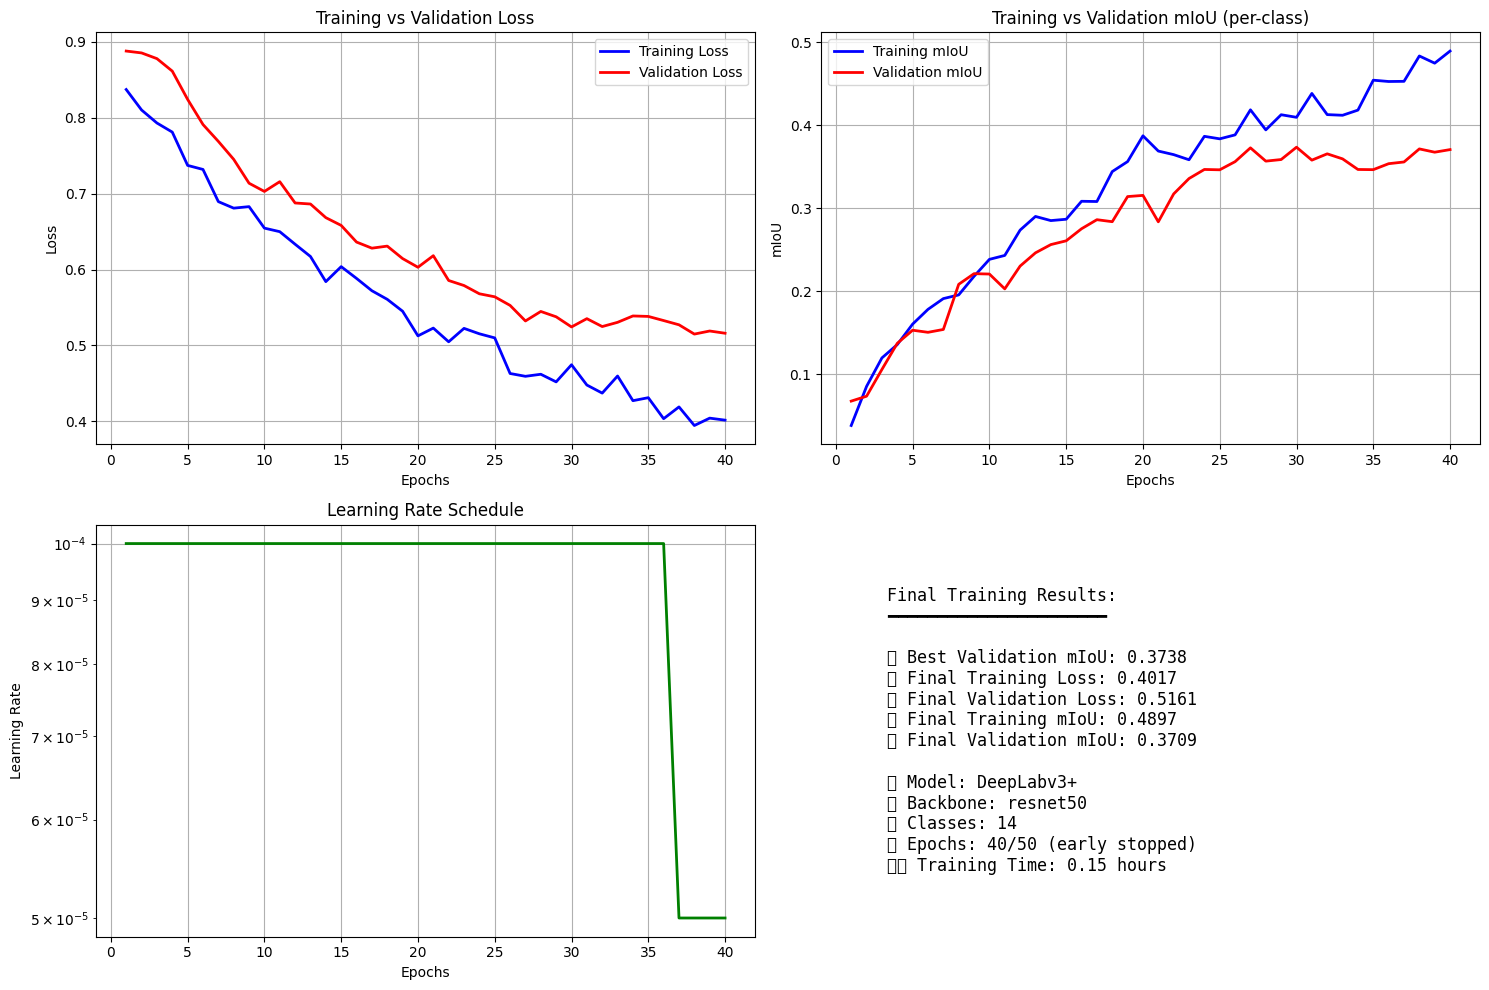

✅ Training visualization complete!
📊 Plot saved to: logs/training_results.png

🎯 TRAINING SUMMARY
✅ Status: TRAINED MODEL READY!
🏗️ Architecture: DeepLabv3+ with resnet50
📊 Classes: 14
🏆 Best mIoU: 0.3738
📅 Epochs: 40/50 (early stopped)
💾 Best model: models/best_DeepLabv3+_resnet50_epoch_30.pth
💾 Final model: models/final_DeepLabv3+_resnet50.pth


In [26]:
# 📈 Plot Training Results (with corrected LR schedule — §3.6 fix)
import matplotlib.pyplot as plt

# Create training plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Loss plots
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# mIoU plots (per-class mean, not binary)
ax2.plot(epochs, train_ious, 'b-', label='Training mIoU', linewidth=2)
ax2.plot(epochs, val_ious, 'r-', label='Validation mIoU', linewidth=2)
ax2.set_title('Training vs Validation mIoU (per-class)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('mIoU')
ax2.legend()
ax2.grid(True)

# Learning rate plot — uses actual per-epoch values (§3.6 fix)
ax3.plot(epochs, learning_rates[:len(epochs)], 'g-', linewidth=2)
ax3.set_title('Learning Rate Schedule')
ax3.set_xlabel('Epochs')
ax3.set_ylabel('Learning Rate')
ax3.set_yscale('log')
ax3.grid(True)

# Best metrics summary
actual_epochs = len(train_losses)
metrics_text = f"""
Final Training Results:
━━━━━━━━━━━━━━━━━━━━━━

🏆 Best Validation mIoU: {best_val_iou:.4f}
📉 Final Training Loss: {train_losses[-1]:.4f}
📉 Final Validation Loss: {val_losses[-1]:.4f}
📊 Final Training mIoU: {train_ious[-1]:.4f}
📊 Final Validation mIoU: {val_ious[-1]:.4f}

🔧 Model: {MODEL_ARCH}
🔧 Backbone: {BACKBONE}
🔧 Classes: {NUM_CLASSES}
📅 Epochs: {actual_epochs}/{NUM_EPOCHS}{' (early stopped)' if actual_epochs < NUM_EPOCHS else ''}
⏱️ Training Time: {training_time/3600:.2f} hours
"""

ax4.text(0.1, 0.5, metrics_text, transform=ax4.transAxes, fontsize=12,
         verticalalignment='center', fontfamily='monospace')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

plt.tight_layout()
plt.savefig(f'{LOGS_DIR}/training_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Training visualization complete!")
print(f"📊 Plot saved to: {LOGS_DIR}/training_results.png")

# Print final summary
print("\n" + "="*60)
print("🎯 TRAINING SUMMARY")
print("="*60)
print(f"✅ Status: TRAINED MODEL READY!")
print(f"🏗️ Architecture: {MODEL_ARCH} with {BACKBONE}")
print(f"📊 Classes: {NUM_CLASSES}")
print(f"🏆 Best mIoU: {best_val_iou:.4f}")
print(f"📅 Epochs: {actual_epochs}/{NUM_EPOCHS}{' (early stopped)' if actual_epochs < NUM_EPOCHS else ''}")
print(f"💾 Best model: {best_model_path}")
print(f"💾 Final model: {final_model_path}")
print("="*60)

## 5: 📐 Reusable Evaluation Metrics (Wilk et al. 2022–compatible)

This section provides **reusable functions** for computing the four standard semantic segmentation metrics reported in the literature, specifically those used by Wilk et al. (2022):

| Metric | What it measures |
|--------|-----------------|
| **mIoU** (mean Intersection over Union) | Average per-class overlap between prediction and ground truth |
| **OA** (Overall Accuracy) | Fraction of all pixels correctly classified |
| **mAcc** (mean Accuracy) | Average per-class recall |
| **mF1** (mean F1-score) | Average per-class harmonic mean of precision and recall |

**Reference:** Wilk, Ł. et al. (2022). "Automatic classification of roof types from 3D building models using semantic segmentation." *ISPRS Archives*, XLIII-B2-2022, 485–492.

### 5.1: 🧮 SegmentationMetrics Class

A confusion-matrix-based metric accumulator that computes mIoU, OA, mAcc, mF1 (per-class and mean). Designed to be called after training to produce results comparable with Wilk et al. (2022).

**How it works:**
1. `update()` — accumulates predictions into a K×K confusion matrix across batches.
2. `compute()` — derives all metrics from the confusion matrix in one pass.
3. `to_dataframe()` / `export_csv()` — export per-class and mean metrics.

In [27]:
# 🧮 SegmentationMetrics — Confusion-matrix-based evaluation
# Computes mIoU, OA, mAcc, mF1 compatible with Wilk et al. (2022)

import torch
import numpy as np
import pandas as pd
from typing import Dict, List, Optional

class SegmentationMetrics:
    """
    Accumulates a confusion matrix across batches and derives
    mIoU, OA, mAcc, mF1 (per-class and mean).

    Usage:
        metrics = SegmentationMetrics(num_classes=14, class_names=class_names)
        for images, masks in val_loader:
            preds = model(images).argmax(dim=1)
            metrics.update(preds, masks)
        results = metrics.compute()
    """

    def __init__(self, num_classes: int, class_names: Optional[List[str]] = None,
                 device: str = 'cpu'):
        self.num_classes = num_classes
        self.class_names = class_names or [f'class_{i}' for i in range(num_classes)]
        self.device = device
        self.confusion_matrix = torch.zeros(
            num_classes, num_classes, dtype=torch.int64, device=device
        )

    def reset(self):
        """Reset the confusion matrix to zeros."""
        self.confusion_matrix.zero_()

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        """
        Accumulate predictions into the confusion matrix.

        Args:
            preds: (N, H, W) tensor of predicted class indices (argmax of logits).
            targets: (N, H, W) tensor of ground-truth class indices.
        """
        preds = preds.to(self.device).view(-1)
        targets = targets.to(self.device).view(-1)

        # Filter out invalid indices
        valid = (targets >= 0) & (targets < self.num_classes) & \
                (preds >= 0) & (preds < self.num_classes)
        preds = preds[valid]
        targets = targets[valid]

        # Compute linear indices and accumulate
        indices = targets * self.num_classes + preds
        self.confusion_matrix += torch.bincount(
            indices, minlength=self.num_classes ** 2
        ).reshape(self.num_classes, self.num_classes)

    def compute(self) -> Dict:
        """
        Derive all metrics from the accumulated confusion matrix.

        Returns:
            dict with keys: 'OA', 'mIoU', 'mAcc', 'mF1', 'per_class'
            where per_class[class_name] = {'iou', 'accuracy', 'precision', 'f1'}
        """
        cm = self.confusion_matrix.float()
        eps = 1e-8

        # Overall Accuracy
        oa = cm.diag().sum() / (cm.sum() + eps)

        # Per-class metrics
        per_class = {}
        ious, accs, precs, f1s = [], [], [], []

        for i in range(self.num_classes):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp          # true class i, predicted as other
            fp = cm[:, i].sum() - tp          # other classes predicted as i

            # IoU = TP / (TP + FP + FN)
            iou = tp / (tp + fp + fn + eps)
            # Accuracy (Recall) = TP / (TP + FN)
            acc = tp / (tp + fn + eps)
            # Precision = TP / (TP + FP)
            prec = tp / (tp + fp + eps)
            # F1 = 2 * Precision * Recall / (Precision + Recall)
            f1 = 2 * prec * acc / (prec + acc + eps)

            per_class[self.class_names[i]] = {
                'iou': iou.item(),
                'accuracy': acc.item(),
                'precision': prec.item(),
                'f1': f1.item(),
            }
            ious.append(iou.item())
            accs.append(acc.item())
            precs.append(prec.item())
            f1s.append(f1.item())

        return {
            'OA': oa.item(),
            'mIoU': np.mean(ious),
            'mAcc': np.mean(accs),
            'mF1': np.mean(f1s),
            'per_class': per_class,
            'confusion_matrix': cm.cpu().numpy(),
        }

    def to_dataframe(self) -> pd.DataFrame:
        """
        Return a DataFrame with per-class metrics + a 'mean' row.
        Columns: class, iou, accuracy, precision, f1
        """
        results = self.compute()
        rows = []
        for cls_name in self.class_names:
            m = results['per_class'][cls_name]
            rows.append({
                'class': cls_name,
                'iou': m['iou'],
                'accuracy': m['accuracy'],
                'precision': m['precision'],
                'f1': m['f1'],
            })
        # Mean row
        rows.append({
            'class': 'mean',
            'iou': results['mIoU'],
            'accuracy': results['mAcc'],
            'precision': np.mean([r['precision'] for r in rows[:-1]]),
            'f1': results['mF1'],
        })
        return pd.DataFrame(rows)

    def export_csv(self, path: str):
        """Export per-class metrics to CSV."""
        df = self.to_dataframe()
        df.to_csv(path, index=False, float_format='%.4f')
        print(f"💾 Metrics exported to {path}")
        return df


# ✅ Wilk et al. (2022) reference benchmarks for comparison
WILK_2022_BENCHMARKS = {
    'image': {
        'mIoU': 60.3,
        'OA':   84.1,
        'mAcc': 81.4,
        'mF1':  72.0,
    },
    'texture_voting': {
        'mIoU': 63.8,
        'OA':   89.9,
        'mAcc': 89.8,
        'mF1':  73.5,
    },
}

print("✅ SegmentationMetrics class defined")
print("✅ Wilk et al. (2022) benchmark values loaded")
print(f"   Reference (image):          mIoU={WILK_2022_BENCHMARKS['image']['mIoU']}%  OA={WILK_2022_BENCHMARKS['image']['OA']}%")
print(f"   Reference (texture voting): mIoU={WILK_2022_BENCHMARKS['texture_voting']['mIoU']}%  OA={WILK_2022_BENCHMARKS['texture_voting']['OA']}%")

✅ SegmentationMetrics class defined
✅ Wilk et al. (2022) benchmark values loaded
   Reference (image):          mIoU=60.3%  OA=84.1%
   Reference (texture voting): mIoU=63.8%  OA=89.9%


### 5.2: 🔬 Model Evaluation Helper

`evaluate_model()` runs the trained model on an entire DataLoader in `eval()` mode and returns a `SegmentationMetrics` result with all four benchmark-comparable metrics.

In [28]:
# 🔬 Evaluate a trained model on a DataLoader and return full metrics

from tqdm import tqdm

def evaluate_model(model, dataloader, num_classes, class_names=None, device='cpu'):
    """
    Run the model on an entire DataLoader and compute all segmentation metrics.

    Args:
        model: Trained PyTorch segmentation model.
        dataloader: DataLoader for the evaluation set.
        num_classes: Number of segmentation classes.
        class_names: Optional list of class name strings.
        device: 'cuda' or 'cpu'.

    Returns:
        SegmentationMetrics instance with accumulated results.
    """
    metrics = SegmentationMetrics(
        num_classes=num_classes,
        class_names=class_names,
        device=device
    )
    model.eval()

    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="🔬 Evaluating"):
            images = images.to(device)
            masks = masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            metrics.update(preds, masks)

    return metrics

print("✅ evaluate_model() defined")

✅ evaluate_model() defined


### 5.3: 📊 Visualization Helpers

Reusable plotting functions:
- `plot_training_curves()` — 4-panel figure: Loss, IoU, LR schedule, summary text
- `plot_confusion_matrix()` — Normalized heatmap with class labels
- `plot_wilk_comparison()` — Grouped bar chart comparing our results vs Wilk et al. (2022)

In [29]:
# 📊 Visualization helpers for training curves, confusion matrix, and Wilk comparison

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os


def plot_training_curves(train_losses, val_losses, train_ious, val_ious,
                         learning_rates, model_arch, backbone, num_classes,
                         best_val_iou, training_time_hours,
                         save_dir='logs', filename='training_results.png'):
    """
    Plot 4-panel training visualization with correct LR tracking.

    Args:
        train_losses, val_losses: Lists of loss values per epoch.
        train_ious, val_ious: Lists of IoU values per epoch.
        learning_rates: List of LR values per epoch (fixes the flat-line bug).
        model_arch, backbone: Model metadata for the summary panel.
        num_classes: Number of segmentation classes.
        best_val_iou: Best validation IoU achieved.
        training_time_hours: Total training time in hours.
        save_dir: Directory for output file.
        filename: Output filename.

    Returns:
        matplotlib Figure object.
    """
    os.makedirs(save_dir, exist_ok=True)
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    epochs = range(1, len(train_losses) + 1)

    # Panel 1: Loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.set_title('Training vs Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)

    # Panel 2: IoU
    ax2.plot(epochs, train_ious, 'b-', label='Training IoU', linewidth=2)
    ax2.plot(epochs, val_ious, 'r-', label='Validation IoU', linewidth=2)
    ax2.set_title('Training vs Validation IoU')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('IoU')
    ax2.legend()
    ax2.grid(True)

    # Panel 3: Learning rate (now using actual per-epoch values)
    ax3.plot(epochs, learning_rates, 'g-', linewidth=2)
    ax3.set_title('Learning Rate Schedule')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('Learning Rate')
    ax3.set_yscale('log')
    ax3.grid(True)

    # Panel 4: Summary text
    summary = (
        f"Final Training Results:\n"
        f"{'━' * 30}\n\n"
        f"🏆 Best Val IoU:    {best_val_iou:.4f}\n"
        f"📉 Final Train Loss: {train_losses[-1]:.4f}\n"
        f"📉 Final Val Loss:   {val_losses[-1]:.4f}\n"
        f"📊 Final Train IoU:  {train_ious[-1]:.4f}\n"
        f"📊 Final Val IoU:    {val_ious[-1]:.4f}\n\n"
        f"🔧 Model: {model_arch}\n"
        f"🔧 Backbone: {backbone}\n"
        f"🔧 Classes: {num_classes}\n"
        f"⏱️ Time: {training_time_hours:.2f} h"
    )
    ax4.text(0.1, 0.5, summary, transform=ax4.transAxes, fontsize=12,
             verticalalignment='center', fontfamily='monospace')
    ax4.axis('off')

    plt.tight_layout()
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"💾 Training curves saved to {save_path}")
    return fig


def plot_confusion_matrix(cm, class_names, normalize=True,
                          save_dir='logs', filename='confusion_matrix.png'):
    """
    Plot a confusion matrix heatmap.

    Args:
        cm: (K, K) numpy array confusion matrix.
        class_names: List of class name strings.
        normalize: If True, normalize each row to sum to 1 (shows recall).
        save_dir: Directory for output file.
        filename: Output filename.

    Returns:
        matplotlib Figure object.
    """
    os.makedirs(save_dir, exist_ok=True)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # avoid division by zero
        cm_display = cm / row_sums
        fmt = '.2f'
        title = 'Normalized Confusion Matrix (Recall per class)'
    else:
        cm_display = cm
        fmt = 'd'
        title = 'Confusion Matrix (Pixel counts)'

    fig, ax = plt.subplots(figsize=(max(8, len(class_names)), max(6, len(class_names) * 0.7)))
    im = ax.imshow(cm_display, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel='True label',
        xlabel='Predicted label',
        title=title,
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    # Annotate cells
    thresh = cm_display.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = cm_display[i, j]
            text = f'{val:{fmt}}' if not normalize else f'{val:.2f}'
            ax.text(j, i, text, ha='center', va='center',
                    color='white' if val > thresh else 'black', fontsize=8)

    plt.tight_layout()
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"💾 Confusion matrix saved to {save_path}")
    return fig


def plot_wilk_comparison(our_results: dict, model_label: str = 'Ours',
                         save_dir: str = 'logs',
                         filename: str = 'wilk_comparison.png'):
    """
    Grouped bar chart comparing our metrics against Wilk et al. (2022).

    Args:
        our_results: dict with keys 'mIoU', 'OA', 'mAcc', 'mF1' (values in %).
        model_label: Label for our model in the legend.
        save_dir: Directory for output file.
        filename: Output filename.

    Returns:
        matplotlib Figure object.
    """
    os.makedirs(save_dir, exist_ok=True)

    metrics = ['mIoU', 'OA', 'mAcc', 'mF1']
    wilk_image = [WILK_2022_BENCHMARKS['image'][m] for m in metrics]
    wilk_texture = [WILK_2022_BENCHMARKS['texture_voting'][m] for m in metrics]
    ours = [our_results[m] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width, wilk_image, width, label='Wilk et al. (image)',
                   color='#2196F3', alpha=0.85)
    bars2 = ax.bar(x, wilk_texture, width, label='Wilk et al. (texture voting)',
                   color='#4CAF50', alpha=0.85)
    bars3 = ax.bar(x + width, ours, width, label=model_label,
                   color='#FF9800', alpha=0.95, edgecolor='black', linewidth=0.5)

    ax.set_ylabel('Score (%)')
    ax.set_title('Segmentation Metrics: Our Model vs Wilk et al. (2022)')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 100)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

    # Annotate bars with values
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    save_path = os.path.join(save_dir, filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"💾 Wilk comparison chart saved to {save_path}")
    return fig


def export_summary_csv(model_arch, backbone, num_epochs, results,
                       best_val_iou, training_hours,
                       save_dir='logs', filename='metrics_summary.csv'):
    """
    Export a single-row summary CSV for cross-experiment aggregation.

    Args:
        model_arch, backbone: Model metadata.
        num_epochs: Total epochs trained.
        results: dict from SegmentationMetrics.compute().
        best_val_iou: Best validation IoU from training.
        training_hours: Total training time in hours.
        save_dir: Directory for output file.
        filename: Output filename.
    """
    os.makedirs(save_dir, exist_ok=True)
    row = {
        'model': model_arch,
        'backbone': backbone,
        'epochs': num_epochs,
        'mIoU': f"{results['mIoU'] * 100:.2f}",
        'OA': f"{results['OA'] * 100:.2f}",
        'mAcc': f"{results['mAcc'] * 100:.2f}",
        'mF1': f"{results['mF1'] * 100:.2f}",
        'best_val_iou': f"{best_val_iou:.4f}",
        'training_hours': f"{training_hours:.2f}",
    }
    df = pd.DataFrame([row])
    save_path = os.path.join(save_dir, filename)

    # Append if file exists, otherwise create with header
    if os.path.exists(save_path):
        df.to_csv(save_path, mode='a', header=False, index=False)
    else:
        df.to_csv(save_path, index=False)
    print(f"💾 Summary exported to {save_path}")
    return df


print("✅ Visualization helpers defined:")
print("   • plot_training_curves() — 4-panel training figure (LR bug fixed)")
print("   • plot_confusion_matrix() — normalized heatmap")
print("   • plot_wilk_comparison() — grouped bar chart vs Wilk et al. (2022)")
print("   • export_summary_csv() — single-row CSV for experiment tracking")

✅ Visualization helpers defined:
   • plot_training_curves() — 4-panel training figure (LR bug fixed)
   • plot_confusion_matrix() — normalized heatmap
   • plot_wilk_comparison() — grouped bar chart vs Wilk et al. (2022)
   • export_summary_csv() — single-row CSV for experiment tracking


## 6: 🏆 Post-Training Evaluation & Benchmark Comparison

This section runs the trained model through the full evaluation pipeline:

1. **Load best checkpoint** from training
2. **Compute all metrics** (mIoU, OA, mAcc, mF1) on the validation set
3. **Export per-class metrics** to `logs/metrics_per_class.csv`
4. **Export experiment summary** to `logs/metrics_summary.csv`
5. **Plot confusion matrix** → `logs/confusion_matrix.png`
6. **Compare with Wilk et al. (2022)** → `logs/wilk_comparison.png`

> ⚠️ Run this section **after** the training loop (Section 4) has completed.

🏆 Starting post-training evaluation...

📦 Loading best model checkpoint...
   ✅ Loaded: models/best_DeepLabv3+_resnet50_epoch_30.pth
   📅 Epoch: 30

🔬 Evaluating on validation set...


🔬 Evaluating: 100%|██████████| 2/2 [00:03<00:00,  1.62s/it]



📊 EVALUATION RESULTS (Validation Set)
   mIoU:  35.62%
   OA:    70.93%
   mAcc:  44.74%
   mF1:   46.47%

📋 Per-class metrics:
                          class    iou accuracy precision     f1
# label:color_rgb:parts:actions  0.00%    0.00%     0.00%  0.00%
        Brownfields:178,80,80:: 46.31%   47.12%    96.44% 63.31%
          Buildings:250,50,83:: 72.32%   86.83%    81.23% 83.94%
             Fence:184,61,245::  0.00%    0.00%     0.00%  0.00%
    Ground Surface:255,204,51:: 12.71%   16.90%    33.94% 22.56%
   Lightning Posts:245,147,49::  0.00%    0.00%     0.00%  0.00%
      Parkinglots:140,120,240:: 29.93%   58.72%    37.90% 46.07%
     Paved Surface:52,209,183:: 31.00%   38.18%    62.24% 47.33%
             Pools:51,221,255:: 89.84%   93.25%    96.08% 94.65%
      Road Surface:89,134,179:: 33.18%   43.49%    58.34% 49.83%
     Sports Fields:250,250,55:: 57.63%   69.13%    77.61% 73.12%
         Vegetation:36,179,83:: 67.84%   75.44%    87.07% 80.84%
           Vehicle:204,51,

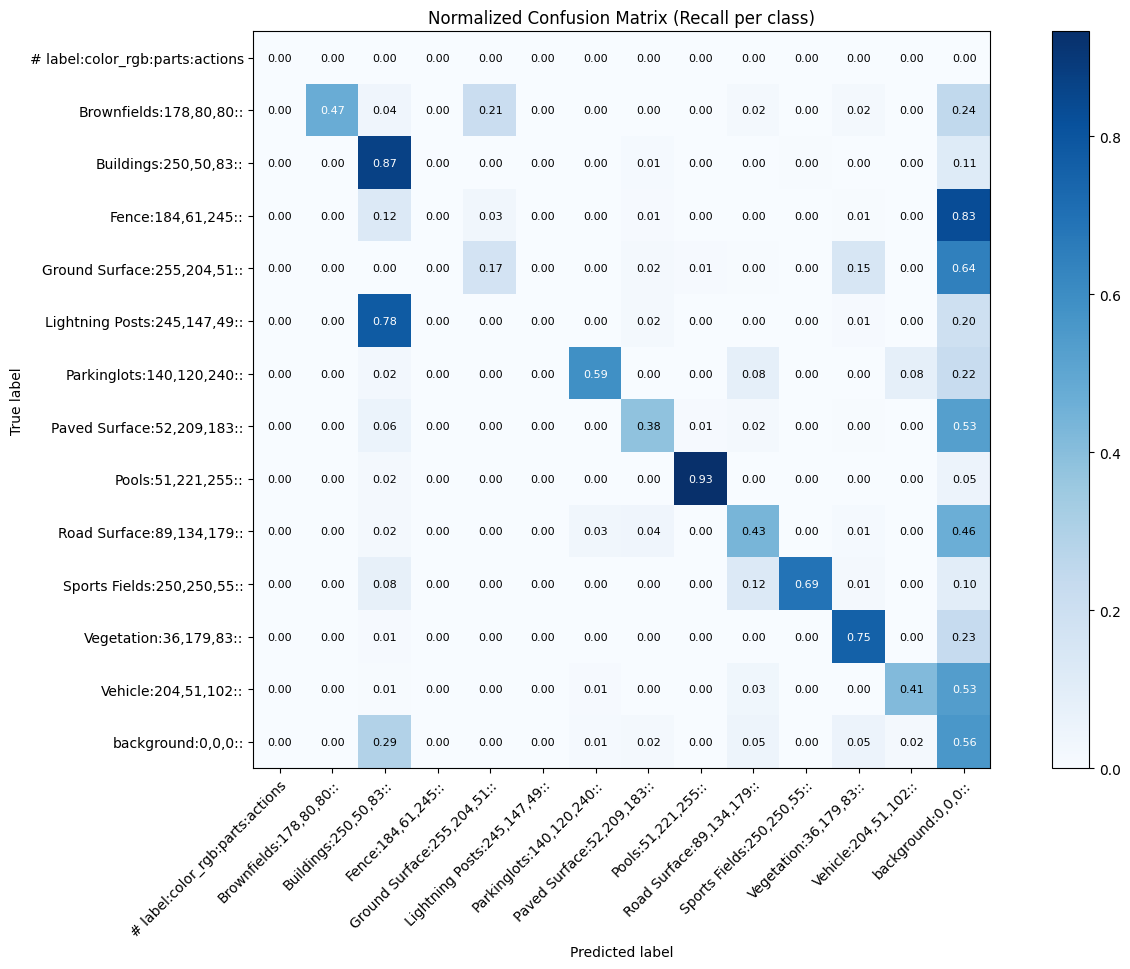


📊 Generating Wilk et al. (2022) comparison...
💾 Wilk comparison chart saved to logs/wilk_comparison.png


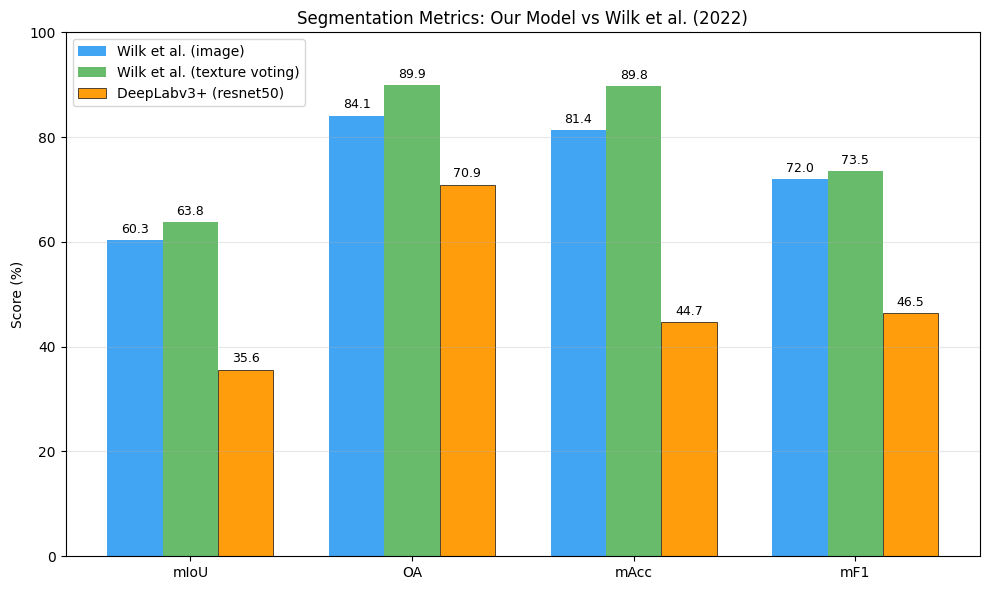


📊 BENCHMARK COMPARISON: Our Model vs Wilk et al. (2022)
Metric  Ours Wilk (image) Wilk (texture) Δ vs image Δ vs texture
  mIoU 35.6%        60.3%          63.8%      -24.7        -28.2
    OA 70.9%        84.1%          89.9%      -13.2        -19.0
  mAcc 44.7%        81.4%          89.8%      -36.7        -45.1
   mF1 46.5%        72.0%          73.5%      -25.5        -27.0

🎯 EVALUATION COMPLETE!
   📁 Per-class metrics: logs/metrics_per_class.csv
   📁 Experiment summary: logs/metrics_summary.csv
   📊 Confusion matrix:   logs/confusion_matrix.png
   📊 Wilk comparison:    logs/wilk_comparison.png


In [30]:
# 🏆 Post-Training Evaluation — Full metrics + Wilk et al. (2022) comparison
# Run this cell AFTER training completes (Section 4)

print("🏆 Starting post-training evaluation...")
print("=" * 60)

# --- Step 1: Load best model checkpoint ---
# weights_only=False is safe here because we saved this checkpoint ourselves
# during training (PyTorch 2.6+ defaults to weights_only=True).
print("\n📦 Loading best model checkpoint...")
checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"   ✅ Loaded: {best_model_path}")
print(f"   📅 Epoch: {checkpoint['epoch']}")

# --- Step 2: Evaluate on validation set ---
print("\n🔬 Evaluating on validation set...")
val_metrics = evaluate_model(
    model=model,
    dataloader=val_loader,
    num_classes=NUM_CLASSES,
    class_names=class_names,
    device=device
)
results = val_metrics.compute()

# --- Step 3: Print full results ---
print("\n" + "=" * 60)
print("📊 EVALUATION RESULTS (Validation Set)")
print("=" * 60)
print(f"   mIoU:  {results['mIoU'] * 100:.2f}%")
print(f"   OA:    {results['OA'] * 100:.2f}%")
print(f"   mAcc:  {results['mAcc'] * 100:.2f}%")
print(f"   mF1:   {results['mF1'] * 100:.2f}%")

print("\n📋 Per-class metrics:")
df_metrics = val_metrics.to_dataframe()
# Display with percentage formatting
df_display = df_metrics.copy()
for col in ['iou', 'accuracy', 'precision', 'f1']:
    df_display[col] = df_display[col].apply(lambda x: f"{x * 100:.2f}%")
print(df_display.to_string(index=False))

# --- Step 4: Export CSVs ---
print("\n💾 Exporting results...")
val_metrics.export_csv(f'{LOGS_DIR}/metrics_per_class.csv')

export_summary_csv(
    model_arch=MODEL_ARCH,
    backbone=BACKBONE,
    num_epochs=NUM_EPOCHS,
    results=results,
    best_val_iou=best_val_iou,
    training_hours=training_time / 3600,
    save_dir=LOGS_DIR,
)

# --- Step 5: Plot confusion matrix ---
print("\n📊 Generating confusion matrix...")
plot_confusion_matrix(
    cm=results['confusion_matrix'],
    class_names=class_names,
    normalize=True,
    save_dir=LOGS_DIR,
)
plt.show()

# --- Step 6: Compare with Wilk et al. (2022) ---
print("\n📊 Generating Wilk et al. (2022) comparison...")
our_results_pct = {
    'mIoU': results['mIoU'] * 100,
    'OA':   results['OA'] * 100,
    'mAcc': results['mAcc'] * 100,
    'mF1':  results['mF1'] * 100,
}
plot_wilk_comparison(
    our_results=our_results_pct,
    model_label=f'{MODEL_ARCH} ({BACKBONE})',
    save_dir=LOGS_DIR,
)
plt.show()

# --- Step 7: Print comparison table ---
print("\n" + "=" * 60)
print("📊 BENCHMARK COMPARISON: Our Model vs Wilk et al. (2022)")
print("=" * 60)
comparison_rows = []
for metric in ['mIoU', 'OA', 'mAcc', 'mF1']:
    row = {
        'Metric': metric,
        'Ours': f"{our_results_pct[metric]:.1f}%",
        'Wilk (image)': f"{WILK_2022_BENCHMARKS['image'][metric]:.1f}%",
        'Wilk (texture)': f"{WILK_2022_BENCHMARKS['texture_voting'][metric]:.1f}%",
        'Δ vs image': f"{our_results_pct[metric] - WILK_2022_BENCHMARKS['image'][metric]:+.1f}",
        'Δ vs texture': f"{our_results_pct[metric] - WILK_2022_BENCHMARKS['texture_voting'][metric]:+.1f}",
    }
    comparison_rows.append(row)
comparison_df = pd.DataFrame(comparison_rows)
print(comparison_df.to_string(index=False))

# --- Summary ---
print("\n" + "=" * 60)
print("🎯 EVALUATION COMPLETE!")
print("=" * 60)
print(f"   📁 Per-class metrics: {LOGS_DIR}/metrics_per_class.csv")
print(f"   📁 Experiment summary: {LOGS_DIR}/metrics_summary.csv")
print(f"   📊 Confusion matrix:   {LOGS_DIR}/confusion_matrix.png")
print(f"   📊 Wilk comparison:    {LOGS_DIR}/wilk_comparison.png")
print("=" * 60)